In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.8 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


###1. Means and Standard Deviations for iSDA soil data

In [ ]:
import ee
import geopandas as gpd

# Initialize
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 1. Load ROI
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# 2. Raw Asset Mapping (Exact names from GEE Catalog)
targets = {
    "ph": "pH",
    "carbon_organic": "Organic_Carbon",
    "nitrogen_total": "Total_Nitrogen",
    "phosphorus_extractable": "Phosphorus",
    "cation_exchange_capacity": "ECEC",
    "calcium_extractable": "Calcium",
    "magnesium_extractable": "Magnesium",
    "potassium_extractable": "Potassium",
    "stone_content": "Stones",
    "bedrock_depth": "Bedrock",
    "texture_class": "Texture",
    "sand_content": "Sand",
    "silt_content": "Silt",
    "clay_content": "Clay",
}

output_folder = 'Nandi_iSDA_Raw_Exports'

# 3. Raw Export Loop
for isda_id, file_label in targets.items():
    try:
        img = ee.Image(f"ISDASOIL/Africa/v1/{isda_id}")

        # Check band names to ensure compatibility with v1
        # Bedrock uses _0_200, others use _0_20
        if isda_id == "bedrock_depth":
            bands = ['mean_0_200', 'stdev_0_200']
        elif isda_id in ["texture_class", "fcc"]:
            bands = ['mean_0_20'] # These usually don't have stdev
        else:
            bands = ['mean_0_20', 'stdev_0_20']

        for b_name in bands:
            # Map band name to a clean suffix (e.g., mean_0_20 -> mean)
            suffix = 'mean' if 'mean' in b_name else 'stdev'
            description = f"{file_label}_{suffix}"

            task = ee.batch.Export.image.toDrive(
                image=img.select(b_name).clip(nandi_roi),
                description=description,
                folder=output_folder,
                region=nandi_roi,
                scale=30,
                crs='EPSG:4326',
                maxPixels=1e9
            )
            task.start()
            print(f"Submitted RAW task: {description}")

    except Exception as e:
        print(f"Skipping {file_label}: {e}")

print("\nAll Raw Tasks Submitted. Monitor: https://code.earthengine.google.com/tasks")

Submitted RAW task: pH_mean
Submitted RAW task: pH_stdev
Submitted RAW task: Organic_Carbon_mean
Submitted RAW task: Organic_Carbon_stdev
Submitted RAW task: Total_Nitrogen_mean
Submitted RAW task: Total_Nitrogen_stdev
Submitted RAW task: Phosphorus_mean
Submitted RAW task: Phosphorus_stdev
Submitted RAW task: ECEC_mean
Submitted RAW task: ECEC_stdev
Submitted RAW task: Calcium_mean
Submitted RAW task: Calcium_stdev
Submitted RAW task: Magnesium_mean
Submitted RAW task: Magnesium_stdev
Submitted RAW task: Potassium_mean
Submitted RAW task: Potassium_stdev
Submitted RAW task: Stones_mean
Submitted RAW task: Stones_stdev
Submitted RAW task: Bedrock_mean
Submitted RAW task: Bedrock_stdev
Submitted RAW task: Texture_mean
Submitted RAW task: Sand_mean
Submitted RAW task: Sand_stdev
Submitted RAW task: Silt_mean
Submitted RAW task: Silt_stdev
Submitted RAW task: Clay_mean
Submitted RAW task: Clay_stdev

All Raw Tasks Submitted. Monitor: https://code.earthengine.google.com/tasks


In [2]:
import ee
import geopandas as gpd
import os

# --- 1. Initialize GEE ---
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# --- 2. Load ROI (Nandi County) ---
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# --- 3. Target Configuration ---
# Only extracting the 20-50cm stdev for these two assets
subsoil_targets = {
    "cation_exchange_capacity": "ECEC",
    "stone_content": "Stones"
}

output_folder = 'Nandi_iSDA_Raw_Exports'

# --- 4. Export Loop ---
for isda_id, file_label in subsoil_targets.items():
    try:
        # Load the specific iSDA Image
        img = ee.Image(f"ISDASOIL/Africa/v1/{isda_id}")

        # Targeted band: 20-50cm Standard Deviation
        b_name = 'stdev_20_50'
        description = f"{file_label}_stdev_20-50cm"

        task = ee.batch.Export.image.toDrive(
            image=img.select(b_name).clip(nandi_roi),
            description=description,
            folder=output_folder,
            region=nandi_roi,
            scale=30,
            crs='EPSG:4326',
            maxPixels=1e9
        )
        task.start()
        print(f"Submitted task: {description}")

    except Exception as e:
        print(f"Error submitting {file_label}: {e}")

print("\nSubsoil uncertainty tasks submitted.")
print("Monitor progress at: https://code.earthengine.google.com/tasks")

Submitted task: ECEC_stdev_20-50cm
Submitted task: Stones_stdev_20-50cm

Subsoil uncertainty tasks submitted.
Monitor progress at: https://code.earthengine.google.com/tasks


In [3]:
import ee
import geopandas as gpd

# --- 1. Initialize GEE ---
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# --- 2. Load ROI (Nandi County) ---
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# --- 3. Target Configuration (Zinc & Iron Only) ---
micronutrient_targets = {
    "zinc_extractable": "Zinc",
    "iron_extractable": "Iron"
}

output_folder = 'Nandi_iSDA_Raw_Exports'

# --- 4. Export Loop ---
for isda_id, file_label in micronutrient_targets.items():
    try:
        # Load the iSDA Asset
        img = ee.Image(f"ISDASOIL/Africa/v1/{isda_id}")

        # Target band: Standard Deviation for 0-20cm
        b_name = 'stdev_0_20'
        description = f"{file_label}_stdev"

        task = ee.batch.Export.image.toDrive(
            image=img.select(b_name).clip(nandi_roi),
            description=description,
            folder=output_folder,
            region=nandi_roi,
            scale=30,
            crs='EPSG:4326',
            maxPixels=1e9
        )
        task.start()
        print(f"Submitted task: {description}")

    except Exception as e:
        print(f"Error submitting {file_label}: {e}")

print("\nZinc and Iron standard deviation tasks submitted.")
print("Monitor progress at: https://code.earthengine.google.com/tasks")

Submitted task: Zinc_stdev
Submitted task: Iron_stdev

Zinc and Iron standard deviation tasks submitted.
Monitor progress at: https://code.earthengine.google.com/tasks


In [8]:
import ee
import geopandas as gpd

# --- 1. Initialize GEE ---
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# --- 2. Load ROI (Nandi County) ---
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# --- 3. Target Configuration (Clay Subsoil Only) ---
output_folder = 'Nandi_iSDA_Raw_Exports'

try:
    # Load the Clay Asset
    img = ee.Image("ISDASOIL/Africa/v1/clay_content")

    # Target band: Standard Deviation for 20-50cm
    b_name = 'stdev_20_50'
    description = "Clay_stdev_20-50cm"

    task = ee.batch.Export.image.toDrive(
        image=img.select(b_name).clip(nandi_roi),
        description=description,
        folder=output_folder,
        region=nandi_roi,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"Submitted task: {description}")

except Exception as e:
    print(f"Error submitting Clay: {e}")

print("\nClay subsoil uncertainty task submitted.")
print("Monitor progress at: https://code.earthengine.google.com/tasks")

Submitted task: Clay_stdev_20-50cm

Clay subsoil uncertainty task submitted.
Monitor progress at: https://code.earthengine.google.com/tasks


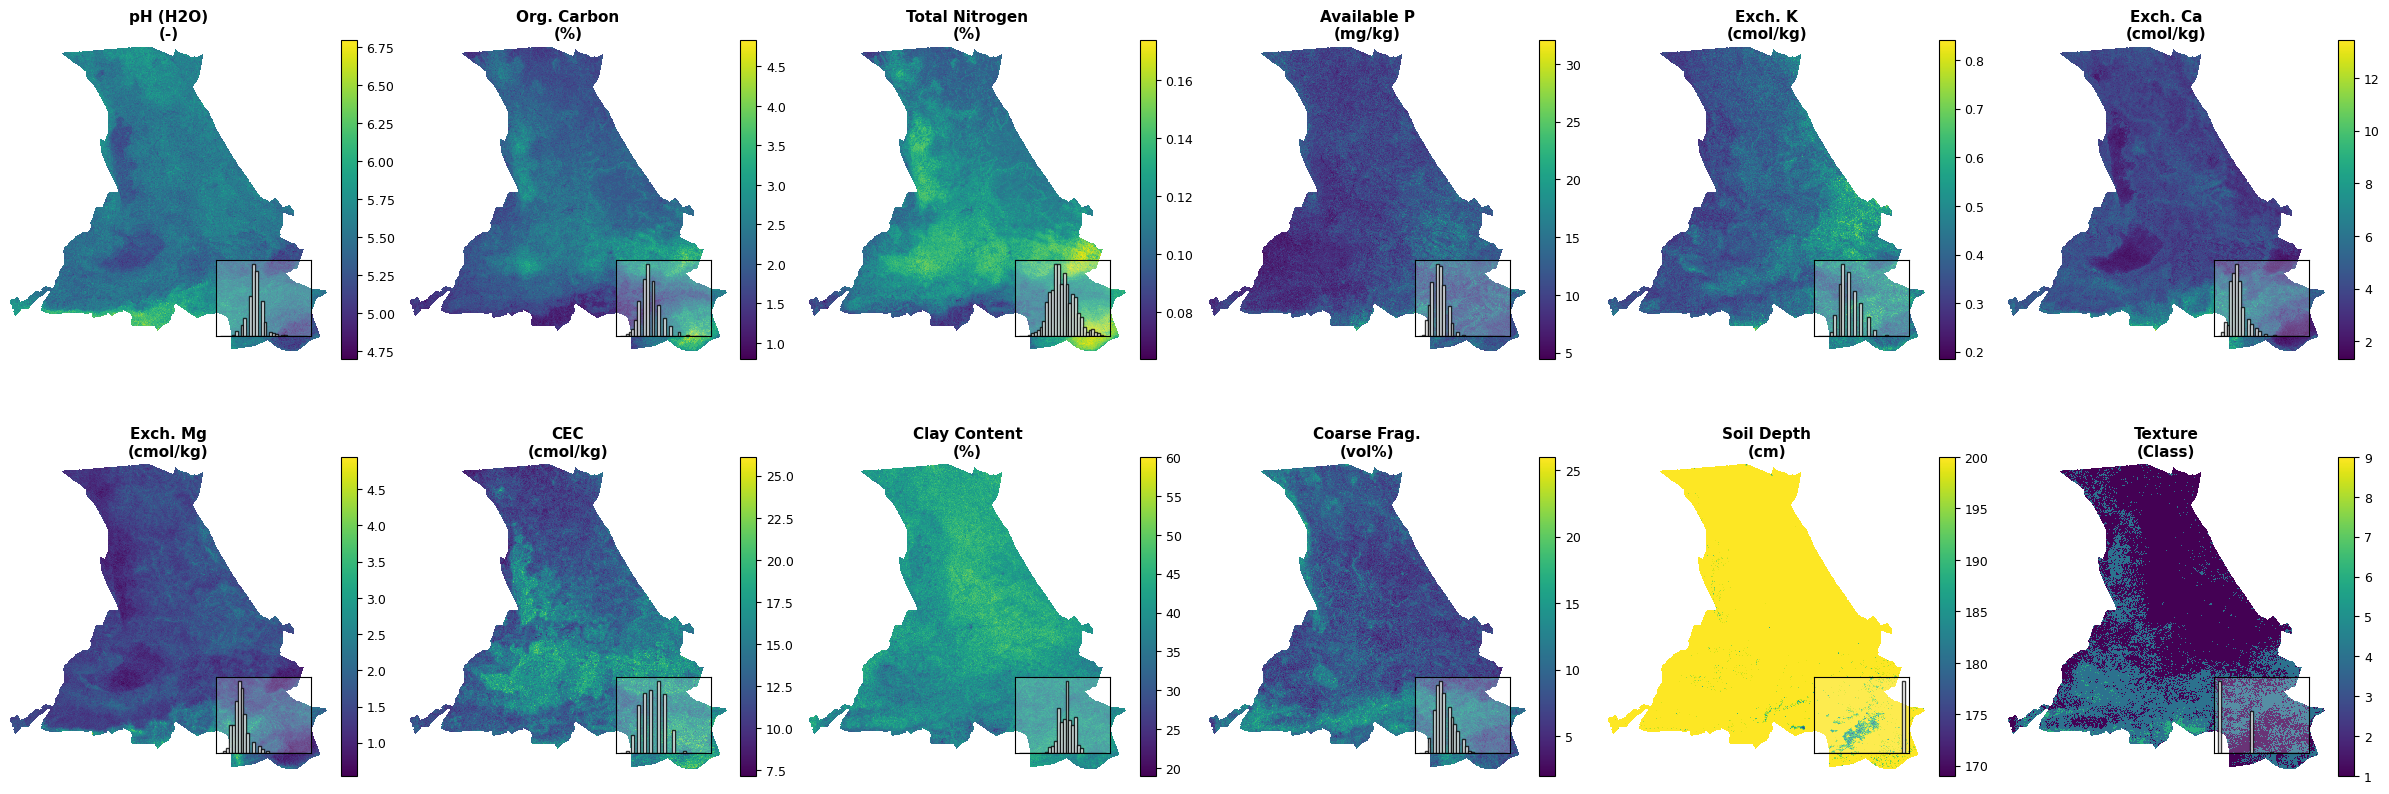

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

base_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Soil_Data/'

# Configuration with the specific Nitrogen fix
file_configs = [
    {'path': 'iSDA_pH_0-20cm.tif', 'label': 'pH (H2O)', 'trans': 'ph', 'unit': '-'},
    {'path': 'iSDA_Organic_Carbon_0-20cm.tif', 'label': 'Org. Carbon', 'trans': 'nut_pct', 'unit': '%'},
    {'path': 'iSDA_Total_Nitrogen_0-20cm.tif', 'label': 'Total Nitrogen', 'trans': 'n_pct', 'unit': '%'},
    {'path': 'iSDA_Phosphorus_0-20cm.tif', 'label': 'Available P', 'trans': 'nut_raw', 'unit': 'mg/kg'},
    {'path': 'iSDA_Potassium_0-20cm.tif', 'label': 'Exch. K', 'trans': 'k_cmol', 'unit': 'cmol/kg'},
    {'path': 'iSDA_Calcium_0-20cm.tif', 'label': 'Exch. Ca', 'trans': 'ca_cmol', 'unit': 'cmol/kg'},
    {'path': 'iSDA_Magnesium_0-20cm.tif', 'label': 'Exch. Mg', 'trans': 'mg_cmol', 'unit': 'cmol/kg'},
    {'path': 'iSDA_cation_exchange_capacity_0-20cm.tif', 'label': 'CEC', 'trans': 'nut_raw', 'unit': 'cmol/kg'},
    {'path': 'iSDA_Clay_Content_0-20cm.tif', 'label': 'Clay Content', 'trans': 'none', 'unit': '%'},
    {'path': 'iSDA_stone_content_0-20cm.tif', 'label': 'Coarse Frag.', 'trans': 'none', 'unit': 'vol%'},
    {'path': 'iSDA_Bedrock_Depth_0-200cm.tif', 'label': 'Soil Depth', 'trans': 'none', 'unit': 'cm'},
    {'path': 'iSDA_Texture_Class_0-20cm.tif', 'label': 'Texture', 'trans': 'none', 'unit': 'Class'}
]

num_cols = 6
num_rows = 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 10))
axes = axes.flatten()

for i, cfg in enumerate(file_configs):
    full_path = os.path.join(base_path, cfg['path'])
    ax = axes[i]

    try:
        with rasterio.open(full_path) as src:
            raw = src.read(1).astype('float32')
            raw[raw <= 0] = np.nan

            if cfg['trans'] == 'ph':
                data = raw / 10
            elif cfg['trans'] == 'n_pct':
                # Applied the linear fix to prevent the exponential explosion
                data = raw / 1000
            elif cfg['trans'] in ['nut_pct', 'nut_raw', 'k_cmol', 'ca_cmol', 'mg_cmol']:
                back_transformed = np.expm1(raw / 10)
                if cfg['trans'] == 'nut_pct':
                    data = back_transformed / 10
                elif cfg['trans'] == 'ca_cmol':
                    data = back_transformed / 200.4
                elif cfg['trans'] == 'mg_cmol':
                    data = back_transformed / 121.5
                elif cfg['trans'] == 'k_cmol':
                    data = back_transformed / 391.0
                else:
                    data = back_transformed
            else:
                data = raw

            im = ax.imshow(data, cmap='viridis', interpolation='nearest')
            ax.set_title(f"{cfg['label']}\n({cfg['unit']})", fontsize=11, fontweight='bold')
            ax.axis('off')

            # Inset Histogram for distribution view
            ax_ins = ax.inset_axes([0.65, 0.05, 0.3, 0.25])
            ax_ins.hist(data[~np.isnan(data)], bins=30, color='white', alpha=0.8, edgecolor='black', lw=0.5)
            ax_ins.set_xticks([]); ax_ins.set_yticks([]); ax_ins.patch.set_alpha(0.2)

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=9)

    except Exception:
        ax.text(0.5, 0.5, f"Missing:\n{cfg['label']}", ha='center', va='center', fontsize=10)
        ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- SAVE THE FIGURE ---
output_filename = 'Nandi_Soil_Analysis_Final.png'
plt.savefig(output_filename, dpi=120, bbox_inches='tight')

plt.show()

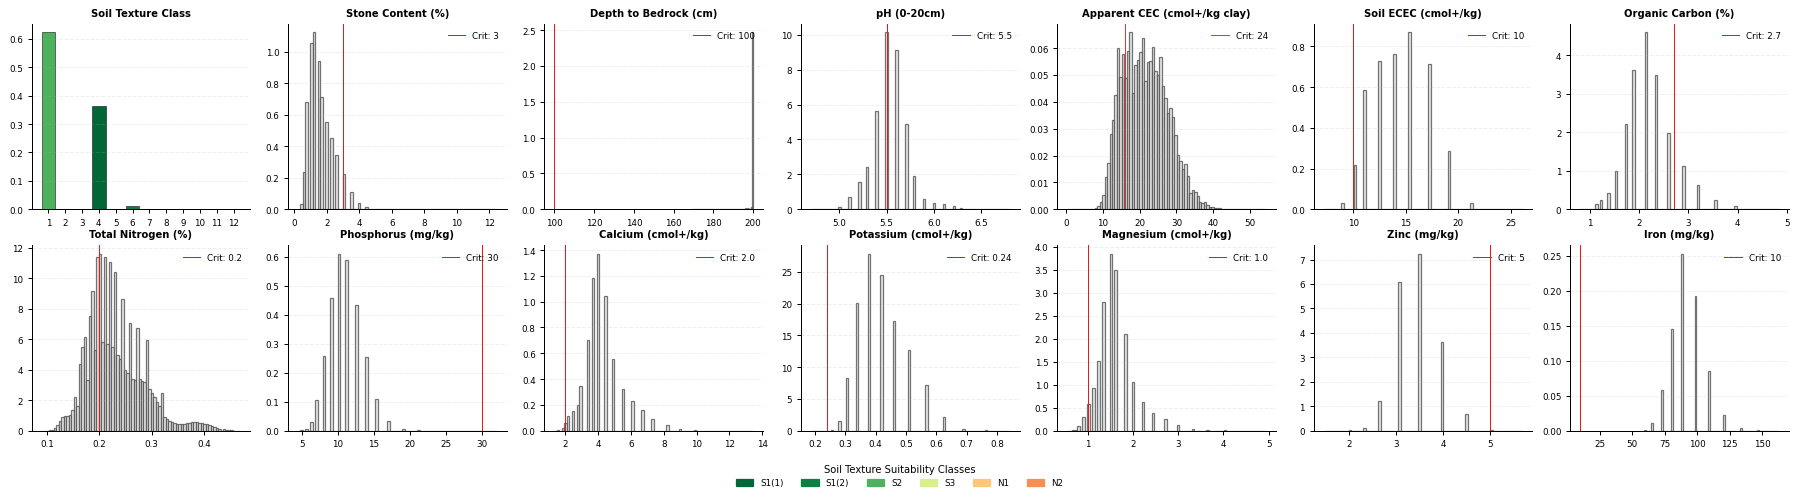

Figure saved to: /content/drive/MyDrive/02_NandiSeedRecommender2/Images/Nandi_Soil_Journal_Distributions_7x2.png


In [39]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Configuration
BASE         = '/content/drive/MyDrive/02_NandiSeedRecommender2'
DIR_SOIL     = os.path.join(BASE, 'Soil_Data')
DIR_IMAGES   = os.path.join(BASE, 'Images')
os.makedirs(DIR_IMAGES, exist_ok=True)

def load_and_clean(fname, transform_func):
    path = os.path.join(DIR_SOIL, fname)
    if not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
    data = transform_func(data)
    data[data <= 0] = np.nan
    return data

def run_final_soil_plots():
    # Variable Map - Updated labels to cmol+/kg
    soil_configs = {
        'Soil Texture Class':    ('iSDA_Texture_Class_0-20cm.tif', lambda x: x),
        'Stone Content (%)':     ('iSDA_stone_content_0-20cm.tif', lambda x: np.expm1(x / 10.0)),
        'Depth to Bedrock (cm)': ('iSDA_Bedrock_Depth_0-200cm.tif', lambda x: x),
        'pH (0-20cm)':           ('iSDA_pH_0-20cm.tif', lambda x: x / 10.0),
        'Soil ECEC (cmol+/kg)':  ('iSDA_cation_exchange_capacity_0-20cm.tif', lambda x: np.expm1(x / 10.0)),
        'Organic Carbon (%)':    ('iSDA_Organic_Carbon_0-20cm.tif', lambda x: np.expm1(x / 10.0) / 10.0),
        'Total Nitrogen (%)':    ('iSDA_Total_Nitrogen_0-20cm.tif', lambda x: np.expm1(x / 100.0) / 10.0),
        'Phosphorus (mg/kg)':    ('iSDA_Phosphorus_0-20cm.tif', lambda x: np.expm1(x / 10.0)),
        'Calcium (cmol+/kg)':    ('iSDA_Calcium_0-20cm.tif', lambda x: np.expm1(x / 10.0) / 200.39),
        'Potassium (cmol+/kg)':  ('iSDA_Potassium_0-20cm.tif', lambda x: np.expm1(x / 10.0) / 390.98),
        'Magnesium (cmol+/kg)':  ('iSDA_Magnesium_0-20cm.tif', lambda x: np.expm1(x / 10.0) / 121.53),
        'Zinc (mg/kg)':          ('iSDA_Zinc_0-20cm.tif', lambda x: np.expm1(x / 10.0)),
        'Iron (mg/kg)':          ('iSDA_Iron_0-20cm.tif', lambda x: np.expm1(x / 10.0))
    }

    critical_values = {
        'pH (0-20cm)': 5.5, 'Organic Carbon (%)': 2.7, 'Total Nitrogen (%)': 0.2,
        'Phosphorus (mg/kg)': 30, 'Calcium (cmol+/kg)': 2.0, 'Magnesium (cmol+/kg)': 1.0,
        'Potassium (cmol+/kg)': 0.24, 'Iron (mg/kg)': 10, 'Zinc (mg/kg)': 5,
        'Soil ECEC (cmol+/kg)': 10, 'Stone Content (%)': 3, 'Depth to Bedrock (cm)': 100
    }

    raw_clay = load_and_clean('iSDA_Clay_Content_0-20cm.tif', lambda x: x)
    processed_data = {}
    for label, (fname, func) in soil_configs.items():
        arr = load_and_clean(fname, func)
        if arr is not None: processed_data[label] = arr

    if all(k in processed_data for k in ['Soil ECEC (cmol+/kg)', 'Organic Carbon (%)']) and raw_clay is not None:
        ecec, oc = processed_data['Soil ECEC (cmol+/kg)'], processed_data['Organic Carbon (%)']
        mineral_ecec = np.maximum(0.1, ecec - (2.6 * oc))
        clay_safe = np.where(raw_clay < 1.0, np.nan, raw_clay)
        # Updated label here as well
        processed_data['Apparent CEC (cmol+/kg clay)'] = (mineral_ecec * 100.0) / clay_safe

    final_order = [
        'Soil Texture Class', 'Stone Content (%)', 'Depth to Bedrock (cm)',
        'pH (0-20cm)', 'Apparent CEC (cmol+/kg clay)', 'Soil ECEC (cmol+/kg)',
        'Organic Carbon (%)', 'Total Nitrogen (%)', 'Phosphorus (mg/kg)',
        'Calcium (cmol+/kg)', 'Potassium (cmol+/kg)', 'Magnesium (cmol+/kg)',
        'Zinc (mg/kg)', 'Iron (mg/kg)'
    ]

    texture_suit = {1:0.83, 2:0.25, 3:0.85, 4:1.0, 5:1.0, 6:0.95, 7:0.95, 8:1.0, 9:0.85, 10:1.0, 11:0.77, 12:0.6}
    suit_groups = [
        ('S1(1)', 1.0), ('S1(2)', 0.95), ('S2', 0.83),
        ('S3', 0.6), ('N1', 0.35), ('N2', 0.25)
    ]

    # Reduced DPI to 90 as requested
    plt.rcParams.update({'font.size': 7, 'axes.titlesize': 8, 'figure.dpi': 90, 'font.family': 'sans-serif'})
    fig, axes = plt.subplots(2, 7, figsize=(20, 6))
    axes = axes.flatten()

    for i, label in enumerate(final_order):
        if label not in processed_data: continue
        data = processed_data[label]
        valid_points = data[np.isfinite(data)].flatten()

        if label == 'Soil Texture Class':
            counts = np.bincount(valid_points.astype(int), minlength=13)[1:]
            x_vals = np.arange(1, 13)
            colors = [plt.cm.RdYlGn(texture_suit[x]) for x in x_vals]
            axes[i].bar(x_vals, counts/len(valid_points), color=colors, edgecolor='black', linewidth=0.4)
            axes[i].set_xticks(x_vals)
        else:
            axes[i].hist(valid_points, bins=80, color='#e0e0e0', edgecolor='#525252', alpha=0.8, density=True)
            if label in critical_values:
                axes[i].axvline(critical_values[label], color='#e41a1c', linestyle='-', linewidth=0.8, label=f'Crit: {critical_values[label]}')
            if label == 'Apparent CEC (cmol+/kg clay)':
                axes[i].axvline(16, color='#e41a1c', linestyle='-', linewidth=0.7, label='Crit: 24')
            axes[i].legend(frameon=False, loc='upper right', fontsize=7)

        axes[i].set_title(label, fontweight='bold')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].grid(axis='y', linestyle='--', alpha=0.2)

    legend_patches = [mpatches.Patch(color=plt.cm.RdYlGn(val), label=cls) for cls, val in suit_groups]
    # Adjusted bbox_to_anchor to bring the legend closer to the plots
    fig.legend(handles=legend_patches, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.08),
               title="Soil Texture Suitability Classes", title_fontsize=8, frameon=False, fontsize=7)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)

    save_path = os.path.join(DIR_IMAGES, 'Nandi_Soil_Journal_Distributions_7x2.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to: {save_path}")

run_final_soil_plots()

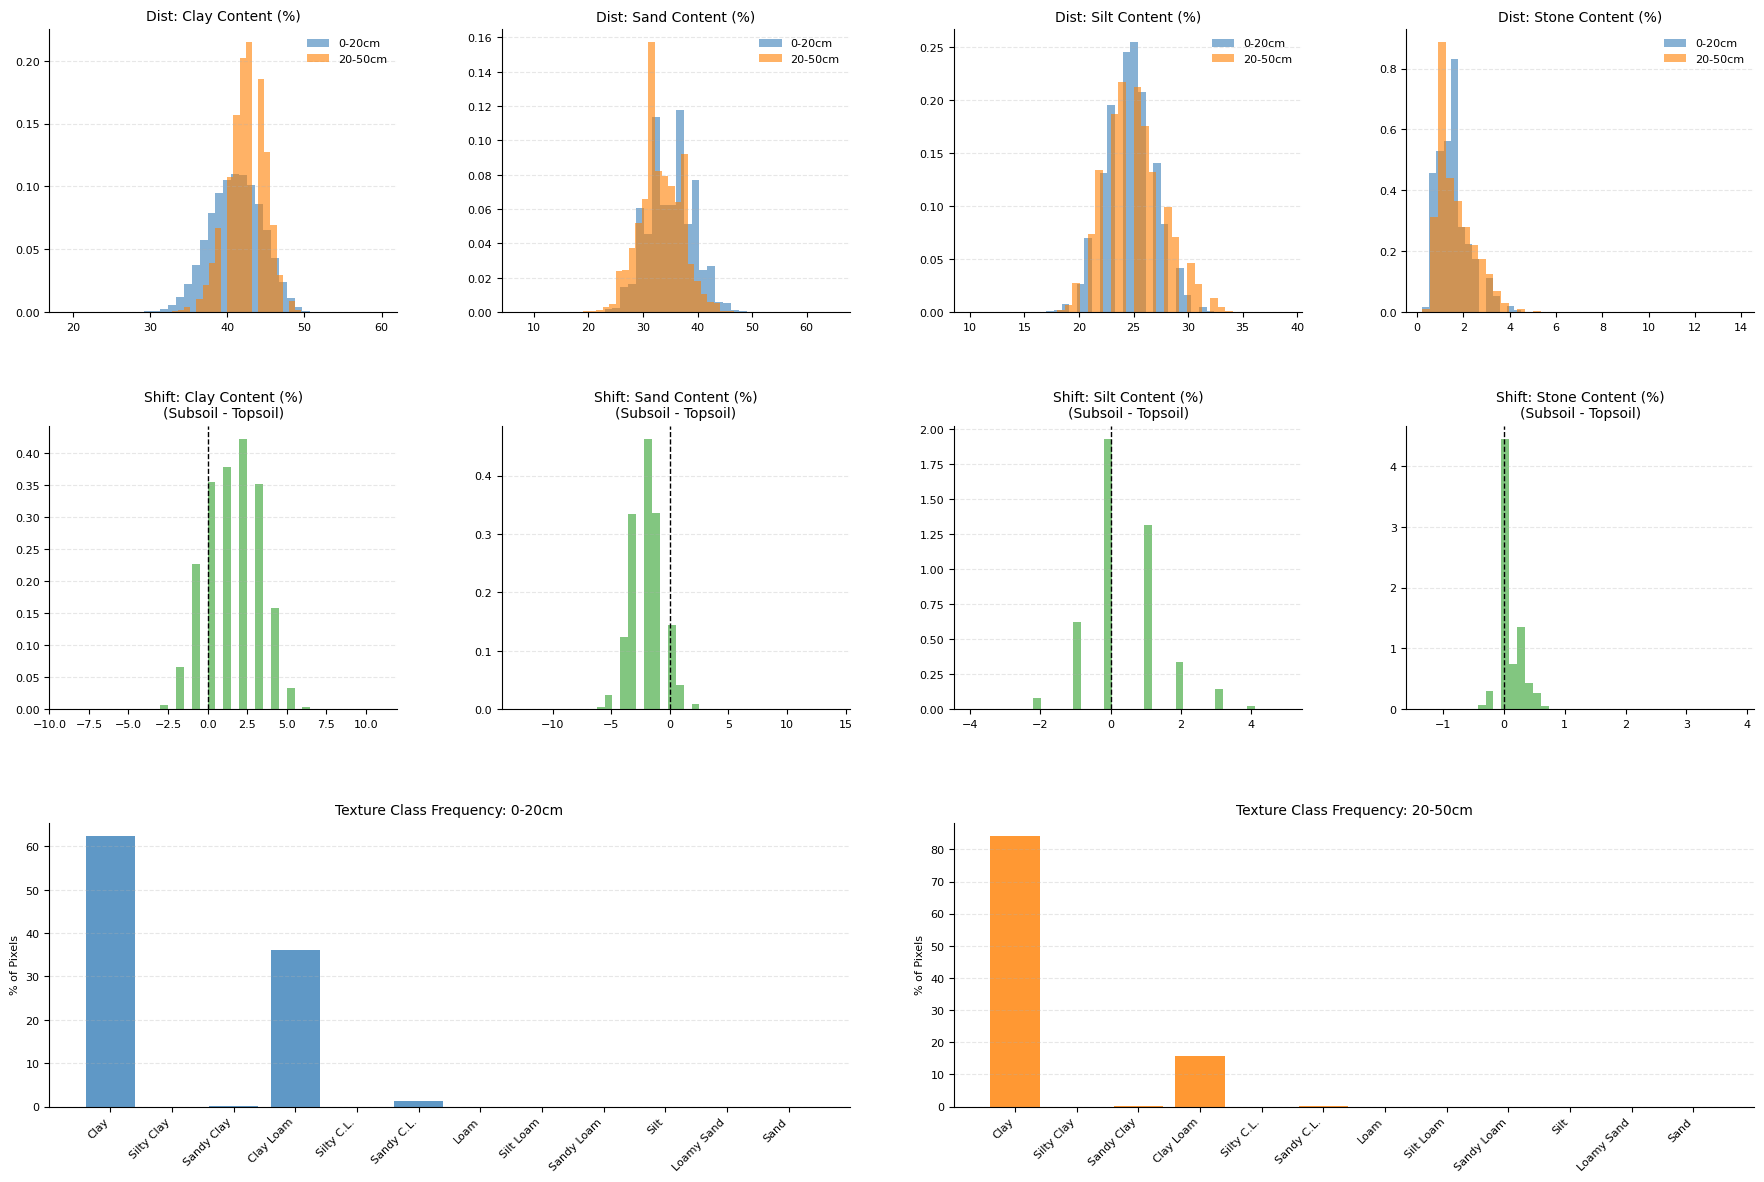

In [8]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from collections import Counter

# --- Texture Configuration ---
TEX_NAMES = {
    1:'Clay', 2:'Silty Clay', 3:'Sandy Clay', 4:'Clay Loam',
    5:'Silty C.L.', 6:'Sandy C.L.', 7:'Loam', 8:'Silt Loam',
    9:'Sandy Loam', 10:'Silt', 11:'Loamy Sand', 12:'Sand'
}

def analyze_soil_profile_comprehensive():
    # 1. Continuous Variables
    pairs = {
        'Clay Content (%)': ('iSDA_Clay_Content_0-20cm.tif', 'iSDA_Clay_Content_20-50cm.tif', lambda x: x),
        'Sand Content (%)': ('iSDA_Sand_Content_0-20cm.tif', 'iSDA_Sand_Content_20-50cm.tif', lambda x: x),
        'Silt Content (%)': ('iSDA_Silt_Content_0-20cm.tif', 'iSDA_Silt_Content_20-50cm.tif', lambda x: x),
        'Stone Content (%)':('iSDA_stone_content_0-20cm.tif', 'iSDA_stone_content_20-50cm.tif', lambda x: np.expm1(x / 10.0))
    }

    # 2. Setup Figure (3 Rows: Distributions, Shifts, and Texture)
    plt.rcParams.update({'font.size': 8, 'axes.titlesize': 10, 'figure.dpi': 100})
    fig = plt.figure(figsize=(22, 14))
    gs = plt.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)

    # --- Process Continuous Pairs ---
    for i, (label, (f1, f2, func)) in enumerate(pairs.items()):
        top = load_and_clean(f1, func)
        sub = load_and_clean(f2, func)

        if top is None or sub is None: continue

        mask = np.isfinite(top) & np.isfinite(sub)
        v_top, v_sub = top[mask], sub[mask]
        diff = v_sub - v_top

        # Row 0: Distribution Overlap
        ax_dist = fig.add_subplot(gs[0, i])
        ax_dist.hist(v_top, bins=40, color='#377eb8', alpha=0.6, label='0-20cm', density=True)
        ax_dist.hist(v_sub, bins=40, color='#ff7f00', alpha=0.6, label='20-50cm', density=True)
        ax_dist.set_title(f'Dist: {label}')
        ax_dist.legend(frameon=False)

        # Row 1: Vertical Shift
        ax_shift = fig.add_subplot(gs[1, i])
        ax_shift.hist(diff, bins=40, color='#4daf4a', alpha=0.7, density=True)
        ax_shift.axvline(0, color='black', linestyle='--', linewidth=1)
        ax_shift.set_title(f'Shift: {label}\n(Subsoil - Topsoil)')

    # --- Process Texture Classes (Row 2) ---
    tx_top_raw = load_and_clean('iSDA_Texture_Class_0-20cm.tif', lambda x: x)
    tx_sub_raw = load_and_clean('iSDA_Texture_Class_20-50cm.tif', lambda x: x)

    def get_counts(arr):
        valid = arr[np.isfinite(arr)].astype(int)
        counts = Counter(valid)
        total = sum(counts.values())
        # Ensure all 12 classes are represented for the plot
        return [counts.get(i, 0) / total * 100 for i in range(1, 13)]

    freq_top = get_counts(tx_top_raw)
    freq_sub = get_counts(tx_sub_raw)
    x_tex = np.arange(1, 13)
    labels_tex = [TEX_NAMES[i] for i in x_tex]

    # Row 2, Col 0-1: Texture 0-20cm
    ax_t1 = fig.add_subplot(gs[2, 0:2])
    ax_t1.bar(x_tex, freq_top, color='#377eb8', alpha=0.8)
    ax_t1.set_xticks(x_tex)
    ax_t1.set_xticklabels(labels_tex, rotation=45, ha='right')
    ax_t1.set_title('Texture Class Frequency: 0-20cm')
    ax_t1.set_ylabel('% of Pixels')

    # Row 2, Col 2-3: Texture 20-50cm
    ax_t2 = fig.add_subplot(gs[2, 2:4])
    ax_t2.bar(x_tex, freq_sub, color='#ff7f00', alpha=0.8)
    ax_t2.set_xticks(x_tex)
    ax_t2.set_xticklabels(labels_tex, rotation=45, ha='right')
    ax_t2.set_title('Texture Class Frequency: 20-50cm')
    ax_t2.set_ylabel('% of Pixels')

    # Clean up spines
    for ax in fig.get_axes():
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    OUT_DIR = '/content/drive/MyDrive/02_NandiSeedRecommender2/Images'
    OUT_FILE = os.path.join(OUT_DIR, 'soil_vertical_analysis.png')

    plt.savefig(OUT_FILE, dpi=90, bbox_inches='tight', facecolor=fig.get_facecolor())

    plt.show()

analyze_soil_profile_comprehensive()

###2. Mean Temperature, Precipitation, and Humidity over previous 10 years (2015-2024)

In [ ]:
import ee
import geopandas as gpd
import time

# 1. Initialize Earth Engine
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 2. Load ROI from your local Shapefile
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
# Standardizing to 'NANDI' as per your previous code
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# 3. Setup Parameters
DRIVE_FOLDER = 'Nandi_Climate_Final'
SCALE_CHIRPS = 5566  # ~5km
SCALE_ERA5   = 9000  # ~9km
CRS          = 'EPSG:4326'

# Collections
CHIRPS = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
ERA5   = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
years  = ee.List.sequence(2015, 2024)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def export_climate_image(image, description, scale):
    task = ee.batch.Export.image.toDrive(
        image=image.clip(nandi_roi),
        description=description,
        folder=DRIVE_FOLDER,
        fileNamePrefix=description,
        region=nandi_roi,
        scale=scale,
        crs=CRS,
        maxPixels=1e10
    )
    task.start()
    print(f"Submitted Climate Task: {description}")

def compute_rh(collection, start_date, end_date):
    """Calculates Relative Humidity % using August-Roche-Magnus"""
    filtered = collection.filterDate(start_date, end_date)
    temp = filtered.select('temperature_2m').mean().subtract(273.15)
    dew  = filtered.select('dewpoint_temperature_2m').mean().subtract(273.15)

    num = dew.multiply(17.625).divide(dew.add(243.04)).exp()
    den = temp.multiply(17.625).divide(temp.add(243.04)).exp()
    return num.divide(den).multiply(100).rename('rh')

# ============================================================
# MAIN PROCESSING ENGINE
# ============================================================

def run_seasonal_extraction(start_month, start_day, label):
    print(f"\n--- Starting {label} Calculations ---")

    # A. 30-Day Physiological Rainfall Blocks (Sys et al. Months 1-4)
    for i in range(4):
        month_idx = i + 1
        annual_prec = years.map(lambda yr:
            CHIRPS.filterDate(
                ee.Date.fromYMD(yr, start_month, start_day).advance(i * 30, 'day'),
                ee.Date.fromYMD(yr, start_month, start_day).advance((i + 1) * 30, 'day')
            ).select('precipitation').sum()
        )
        export_climate_image(ee.ImageCollection(annual_prec).mean(), f"Prec_Month{month_idx}_{label}", SCALE_CHIRPS)

    # B. Seasonal Totals (110 Days)
    seasonal_rain = years.map(lambda yr:
        CHIRPS.filterDate(
            ee.Date.fromYMD(yr, start_month, start_day),
            ee.Date.fromYMD(yr, start_month, start_day).advance(110, 'day')
        ).select('precipitation').sum()
    )
    export_climate_image(ee.ImageCollection(seasonal_rain).mean(), f"Mean_Season_Rain_{label}", SCALE_CHIRPS)

    # C. Temperatures (Mean, Min, Max - 110 Days)
    t_bands = {'temperature_2m': 'MeanTemp', 'temperature_2m_min': 'MinTemp', 'temperature_2m_max': 'MaxTemp'}
    for band, name in t_bands.items():
        annual_temp = years.map(lambda yr:
            ERA5.filterDate(
                ee.Date.fromYMD(yr, start_month, start_day),
                ee.Date.fromYMD(yr, start_month, start_day).advance(110, 'day')
            ).select(band).mean().subtract(273.15)
        )
        export_climate_image(ee.ImageCollection(annual_temp).mean(), f"{name}_{label}", SCALE_ERA5)

    # D. Germination Temp (First 30 Days)
    germin_temp = years.map(lambda yr:
        ERA5.filterDate(
            ee.Date.fromYMD(yr, start_month, start_day),
            ee.Date.fromYMD(yr, start_month, start_day).advance(30, 'day')
        ).select('temperature_2m').mean().subtract(273.15)
    )
    export_climate_image(ee.ImageCollection(germin_temp).mean(), f"GerminationTemp_{label}", SCALE_ERA5)

    # E. Relative Humidity (Physiological Stages)
    # Dev: Month 2 (Days 31-60) | Mat: Final Month (Days 81-110)
    stages = {'Development': [30, 60], 'Maturation': [80, 110]}
    for stage, offsets in stages.items():
        annual_rh = years.map(lambda yr:
            compute_rh(ERA5,
                ee.Date.fromYMD(yr, start_month, start_day).advance(offsets[0], 'day'),
                ee.Date.fromYMD(yr, start_month, start_day).advance(offsets[1], 'day'))
        )
        export_climate_image(ee.ImageCollection(annual_rh).mean(), f"RH_{stage}_{label}", SCALE_ERA5)

# Execute for both seasons
run_seasonal_extraction(3, 25, 'LongRains')
run_seasonal_extraction(10, 25, 'ShortRains')


--- Starting LongRains Calculations ---
Submitted Climate Task: Prec_Month1_LongRains
Submitted Climate Task: Prec_Month2_LongRains
Submitted Climate Task: Prec_Month3_LongRains
Submitted Climate Task: Prec_Month4_LongRains
Submitted Climate Task: Mean_Season_Rain_LongRains
Submitted Climate Task: MeanTemp_LongRains
Submitted Climate Task: MinTemp_LongRains
Submitted Climate Task: MaxTemp_LongRains
Submitted Climate Task: GerminationTemp_LongRains
Submitted Climate Task: RH_Development_LongRains
Submitted Climate Task: RH_Maturation_LongRains

--- Starting ShortRains Calculations ---
Submitted Climate Task: Prec_Month1_ShortRains
Submitted Climate Task: Prec_Month2_ShortRains
Submitted Climate Task: Prec_Month3_ShortRains
Submitted Climate Task: Prec_Month4_ShortRains
Submitted Climate Task: Mean_Season_Rain_ShortRains
Submitted Climate Task: MeanTemp_ShortRains
Submitted Climate Task: MinTemp_ShortRains
Submitted Climate Task: MaxTemp_ShortRains
Submitted Climate Task: GerminationTem


DIAGNOSTIC REPORT: LONGRAINS (10-Year Mean: 2015-2024)
Variable                  | Min        | Max        | Mean       | Unit
--------------------------------------------------------------------------------
GerminationTemp           | 16.01      | 21.49      | 18.70      | °C
MaxTemp                   | 20.11      | 26.44      | 22.97      | °C
MeanTemp                  | 14.78      | 20.77      | 17.76      | °C
Mean_Season_Rain          | 566.88     | 999.12     | 765.84     | mm
MinTemp                   | 10.46      | 17.16      | 13.24      | °C
Prec_Month1               | 154.35     | 314.88     | 232.25     | mm
Prec_Month2               | 170.88     | 378.30     | 269.74     | mm
Prec_Month3               | 92.39      | 197.15     | 150.83     | mm
Prec_Month4               | 93.87      | 240.67     | 183.47     | mm
RH_Development            | 77.52      | 85.34      | 82.06      | %
RH_Maturation             | 72.16      | 84.11      | 78.96      | %


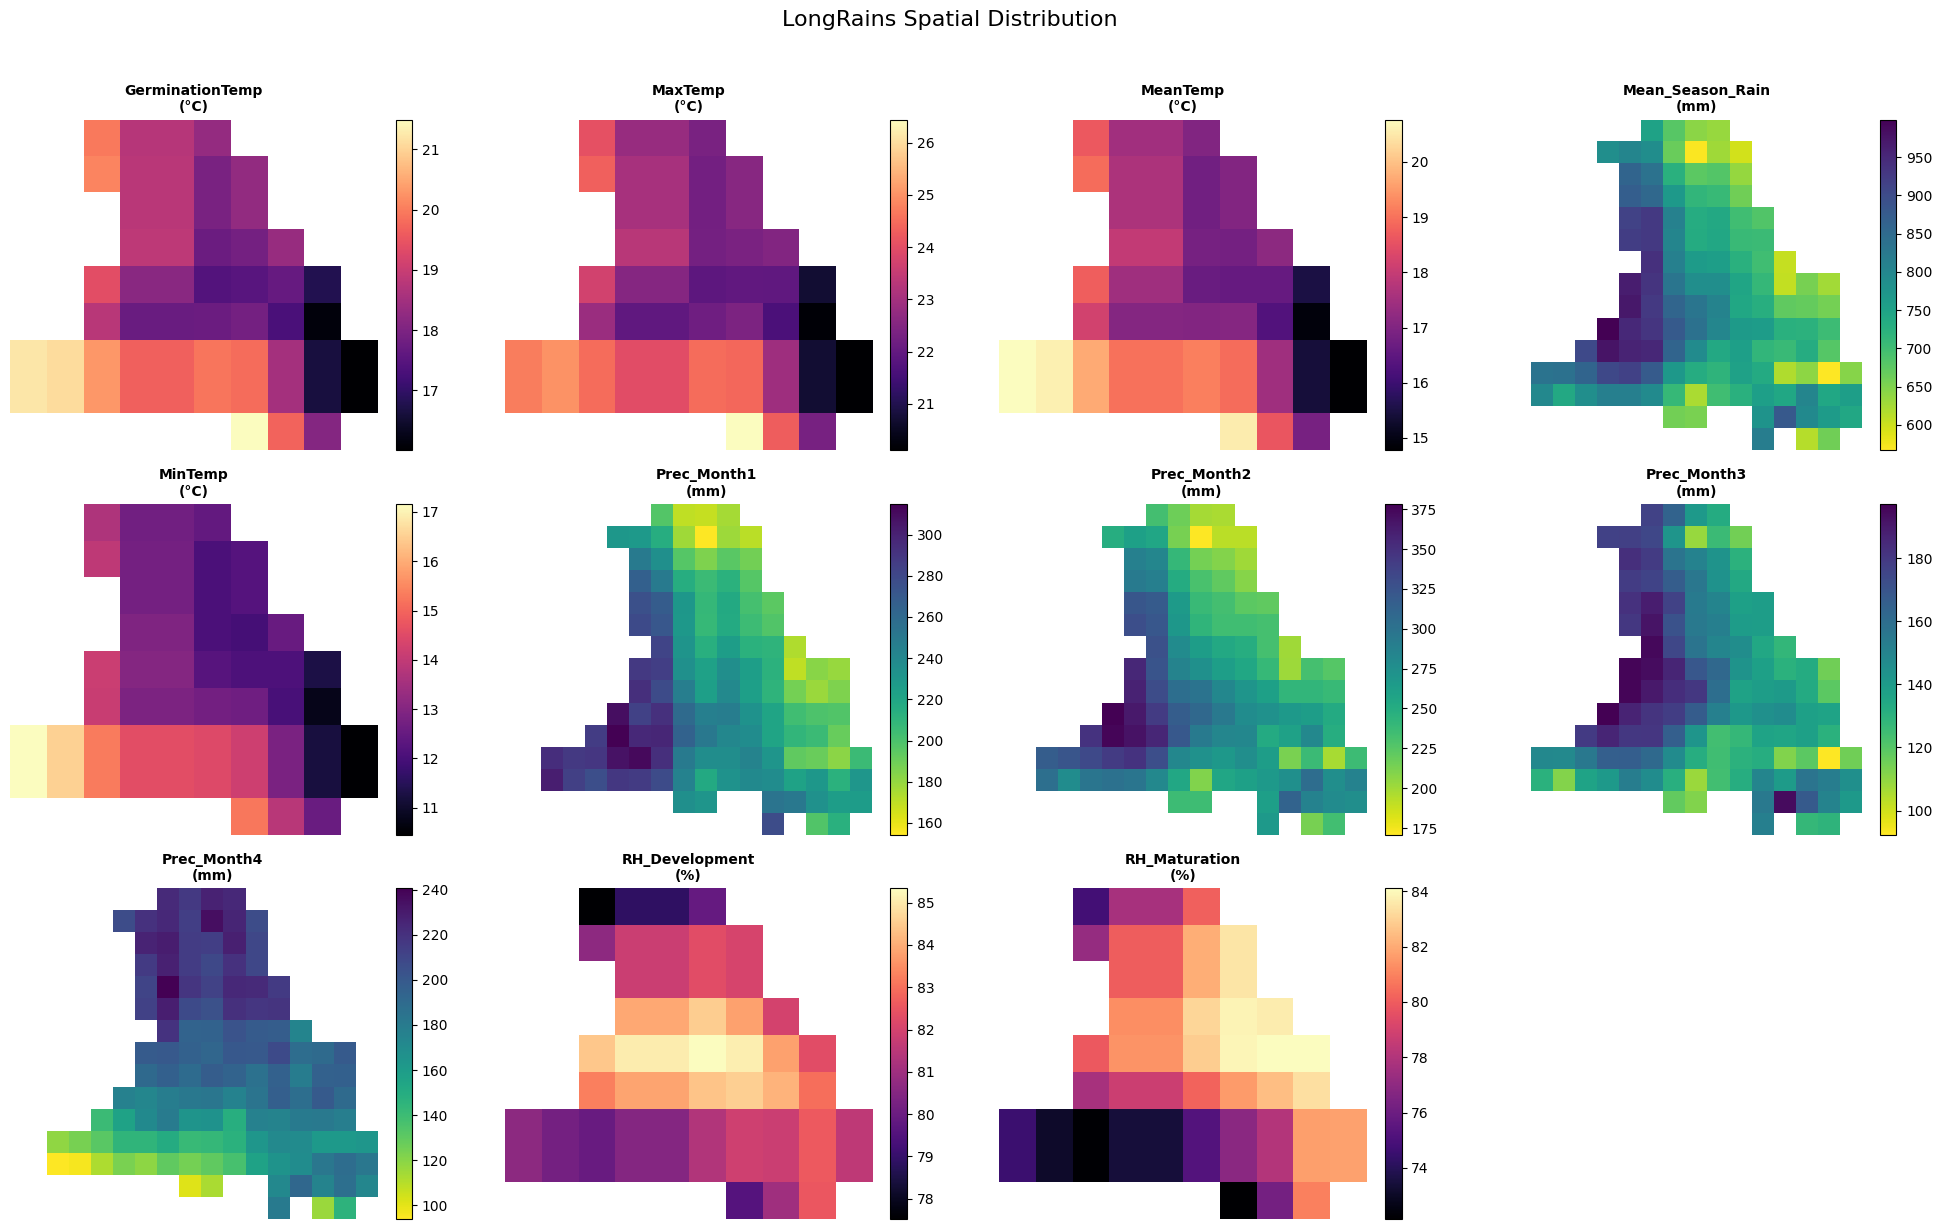


DIAGNOSTIC REPORT: SHORTRAINS (10-Year Mean: 2015-2024)
Variable                  | Min        | Max        | Mean       | Unit
--------------------------------------------------------------------------------
GerminationTemp           | 14.81      | 21.27      | 18.00      | °C
MaxTemp                   | 20.69      | 28.43      | 24.28      | °C
MeanTemp                  | 15.24      | 21.66      | 18.41      | °C
Mean_Season_Rain          | 164.00     | 578.32     | 368.86     | mm
MinTemp                   | 10.63      | 17.06      | 13.20      | °C
Prec_Month1               | 62.25      | 236.82     | 151.44     | mm
Prec_Month2               | 37.81      | 194.75     | 110.76     | mm
Prec_Month3               | 39.30      | 117.34     | 67.69      | mm
Prec_Month4               | 27.72      | 155.28     | 67.63      | mm
RH_Development            | 63.60      | 75.92      | 70.33      | %
RH_Maturation             | 51.23      | 66.95      | 59.72      | %


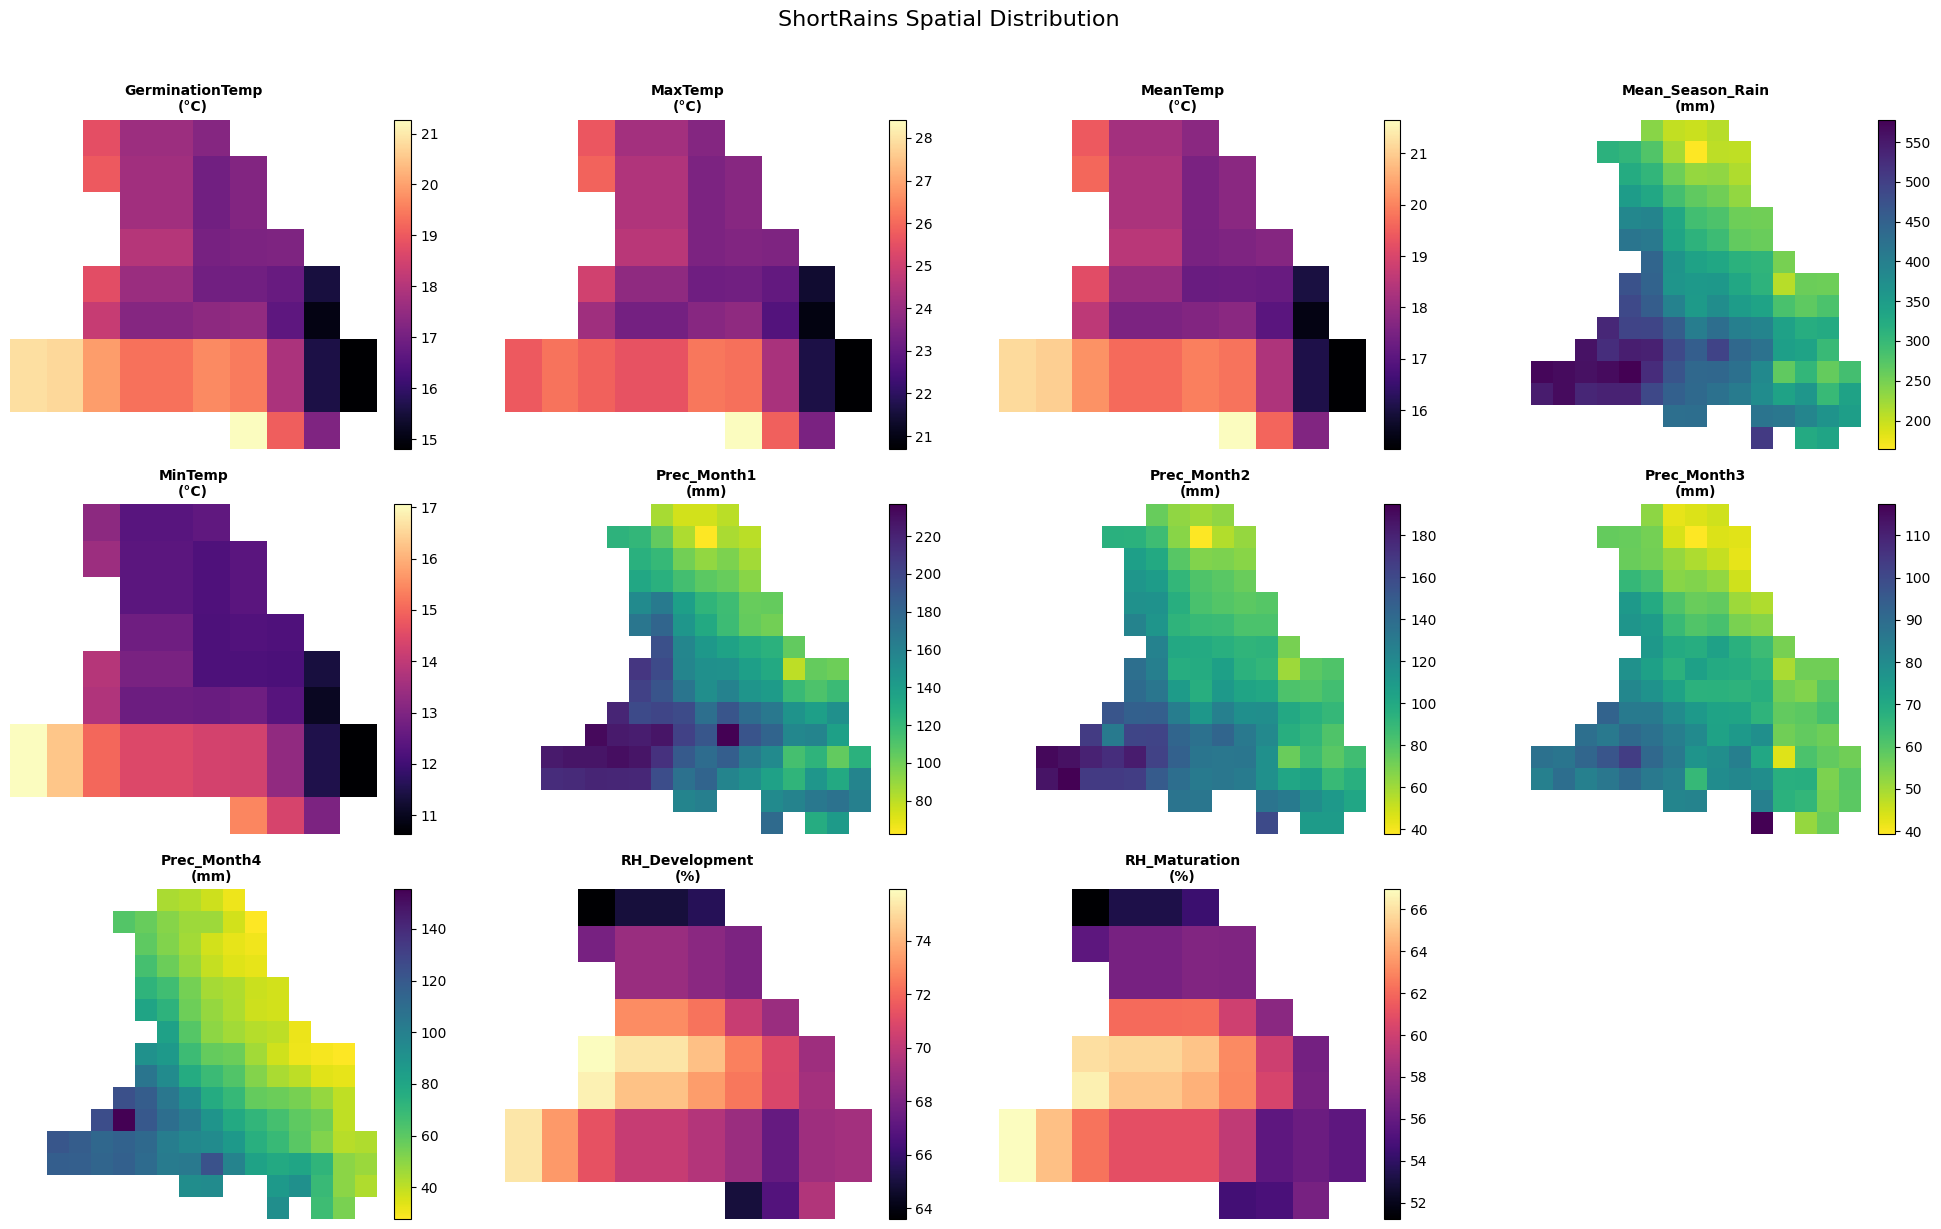

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob

base_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Climate_Data'
seasons = ['LongRains', 'ShortRains']

def run_climate_diagnostic(season):
    # Get all .tif files for the season
    files = sorted(glob(os.path.join(base_path, f"*{season}.tif")))

    if not files:
        print(f"No files found for {season}. Please check the path.")
        return

    print(f"\n{'='*80}")
    print(f"DIAGNOSTIC REPORT: {season.upper()} (10-Year Mean: 2015-2024)")
    print(f"{'Variable':<25} | {'Min':<10} | {'Max':<10} | {'Mean':<10} | {'Unit'}")
    print(f"{'-'*80}")

    # Set up plotting
    num_files = len(files)
    cols = 4
    rows = (num_files // cols) + (1 if num_files % cols > 0 else 0)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()

    for i, f_path in enumerate(files):
        label = os.path.basename(f_path).replace(f"_{season}.tif", "")

        with rasterio.open(f_path) as src:
            data = src.read(1).astype('float32')

            # ERA5 and CHIRPS often use high/low NoData values
            data[(data < -500) | (data > 5000)] = np.nan
            valid_data = data[~np.isnan(data)]

            if valid_data.size > 0:
                v_min, v_max, v_mean = np.min(valid_data), np.max(valid_data), np.mean(valid_data)

                # Print Numerical Stats
                unit = "mm" if "Prec" in label or "Rain" in label else "°C"
                unit = "%" if "RH" in label else unit
                print(f"{label:<25} | {v_min:<10.2f} | {v_max:<10.2f} | {v_mean:<10.2f} | {unit}")

                # Plotting
                cmap = 'viridis_r' if unit == "mm" else 'magma'
                im = axes[i].imshow(data, cmap=cmap)
                axes[i].set_title(f"{label}\n({unit})", fontsize=10, fontweight='bold')
                plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

            axes[i].axis('off')

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{season} Spatial Distribution", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the check
for s in seasons:
    run_climate_diagnostic(s)

###3. Climate Failures

In [ ]:
import ee
import geopandas as gpd

# 1. Initialize
try:
    ee.Initialize(project='nandi-seed-recommender')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='nandi-seed-recommender')

# 2. Load ROI (Using your Shapefile method)
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# 3. Setup Parameters
DRIVE_FOLDER = 'Nandi_Annual_Failures'
ERA5   = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
CHIRPS = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
YEAR_START, YEAR_END = 1981, 2024

# Thresholds
T_MIN_LETHAL, T_MIN_DUR = 5.0, 7
T_MAX_LETHAL, T_MAX_DUR = 32.0, 5
P_MIN_LETHAL, P_MIN_DUR = 1.0, 21
P_MAX_LETHAL, P_MAX_DUR = 100.0, 3

# ============================================================
# LOGIC FUNCTIONS
# ============================================================

def any_consecutive_violation(daily_binary_coll, duration):
    """Checks for 'duration' consecutive days of 1s in a collection"""
    size = daily_binary_coll.size()
    daily_list = daily_binary_coll.toList(size)

    # Create windowed sums (sliding window)
    def calc_window_sum(i):
        window = ee.ImageCollection(daily_list.slice(ee.Number(i), ee.Number(i).add(duration)))
        return window.sum()

    window_sums = ee.List.sequence(0, size.subtract(duration)).map(calc_window_sum)
    # If the maximum sum found equals the duration, it was a consecutive hit
    return ee.ImageCollection(window_sums).max().gte(duration).rename('failure')

def compute_annual_failure(year, label, start_date, end_date):
    era5_s = ERA5.filterDate(start_date, end_date).sort('system:time_start')
    chi_s  = CHIRPS.filterDate(start_date, end_date).sort('system:time_start')

    # 1. Cold Stress (< 5C for 7 days)
    fail_tmin = any_consecutive_violation(
        era5_s.select('temperature_2m_min').map(lambda i: i.subtract(273.15).lt(T_MIN_LETHAL)), T_MIN_DUR)

    # 2. Heat Stress (> 32C for 5 days)
    fail_tmax = any_consecutive_violation(
        era5_s.select('temperature_2m_max').map(lambda i: i.subtract(273.15).gt(T_MAX_LETHAL)), T_MAX_DUR)

    # 3. Drought (< 1mm for 21 days)
    fail_drought = any_consecutive_violation(
        chi_s.select('precipitation').map(lambda i: i.lt(P_MIN_LETHAL)), P_MIN_DUR)

    # 4. Flooding (> 100mm in 3 days) - Using a 3-day rolling sum
    chi_list = chi_s.select('precipitation').toList(chi_s.size())
    def calc_flood(i):
        return ee.ImageCollection(chi_list.slice(ee.Number(i), ee.Number(i).add(3))).sum().gt(P_MAX_LETHAL)

    fail_flood = ee.ImageCollection(ee.List.sequence(0, chi_s.size().subtract(3)).map(calc_flood)).max()

    # Combine
    any_fail = fail_tmin.Or(fail_tmax).Or(fail_drought).Or(fail_flood).rename('failure').clip(nandi_roi)

    # Export
    fname = f"Failure_{label}_{year}"
    task = ee.batch.Export.image.toDrive(
        image=any_fail.toByte(), # Save as 0/1 to save space
        description=fname,
        folder=DRIVE_FOLDER,
        fileNamePrefix=fname,
        region=nandi_roi,
        scale=9000, # Match ERA5
        crs='EPSG:4326'
    )
    task.start()
    print(f"Submitted: {fname}")

# ============================================================
# EXECUTION LOOP
# ============================================================
for yr in range(YEAR_START, YEAR_END + 1):
    # Long Rains
    compute_annual_failure(yr, 'LongRains', f"{yr}-03-25", f"{yr}-07-13")

    # Short Rains (handles year boundary)
    if yr < YEAR_END:
        compute_annual_failure(yr, 'ShortRains', f"{yr}-10-25", f"{yr+1}-02-12")

Submitted: Failure_LongRains_1981
Submitted: Failure_ShortRains_1981
Submitted: Failure_LongRains_1982
Submitted: Failure_ShortRains_1982
Submitted: Failure_LongRains_1983
Submitted: Failure_ShortRains_1983
Submitted: Failure_LongRains_1984
Submitted: Failure_ShortRains_1984
Submitted: Failure_LongRains_1985
Submitted: Failure_ShortRains_1985
Submitted: Failure_LongRains_1986
Submitted: Failure_ShortRains_1986
Submitted: Failure_LongRains_1987
Submitted: Failure_ShortRains_1987
Submitted: Failure_LongRains_1988
Submitted: Failure_ShortRains_1988
Submitted: Failure_LongRains_1989
Submitted: Failure_ShortRains_1989
Submitted: Failure_LongRains_1990
Submitted: Failure_ShortRains_1990
Submitted: Failure_LongRains_1991
Submitted: Failure_ShortRains_1991
Submitted: Failure_LongRains_1992
Submitted: Failure_ShortRains_1992
Submitted: Failure_LongRains_1993
Submitted: Failure_ShortRains_1993
Submitted: Failure_LongRains_1994
Submitted: Failure_ShortRains_1994
Submitted: Failure_LongRains_1995


In [7]:
import ee
import geopandas as gpd

# ============================================================
# 1. INITIALIZATION
# ============================================================
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# ============================================================
# 2. ROI & CONFIGURATION
# ============================================================
# Load ROI using your Shapefile method
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
nandi_roi = ee.Geometry(nandi_gdf.union_all().__geo_interface__)

# Setup Parameters
DRIVE_FOLDER = 'Nandi_Annual_Failures_5Band'
ERA5   = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
CHIRPS = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
YEAR_START, YEAR_END = 1981, 2024

# Stressor Thresholds
T_MIN_LETHAL, T_MIN_DUR = 5.0, 7     # Cold: < 5C for 7 days
T_MAX_LETHAL, T_MAX_DUR = 32.0, 5    # Heat: > 32C for 5 days
P_MIN_LETHAL, P_MIN_DUR = 1.0, 21    # Drought: < 1mm for 21 days
P_MAX_LETHAL, P_MAX_DUR = 100.0, 3   # Flood: > 100mm total over 3 days

# ============================================================
# 3. LOGIC FUNCTIONS
# ============================================================

def any_consecutive_violation(daily_binary_coll, duration, name):
    """Checks for 'duration' consecutive days of 1s in a collection"""
    size = daily_binary_coll.size()
    daily_list = daily_binary_coll.toList(size)

    # Create sliding window sums
    def calc_window_sum(i):
        window = ee.ImageCollection(daily_list.slice(ee.Number(i), ee.Number(i).add(duration)))
        return window.sum()

    window_sums = ee.List.sequence(0, size.subtract(duration)).map(calc_window_sum)
    # If the max sum in the windowed collection equals the duration, it's a failure
    return ee.ImageCollection(window_sums).max().gte(duration).rename(name)

def compute_5band_failure(year, label, start_date, end_date):
    """Computes 4 individual stressors + 1 overall failure band"""
    era5_s = ERA5.filterDate(start_date, end_date).sort('system:time_start')
    chi_s  = CHIRPS.filterDate(start_date, end_date).sort('system:time_start')

    # 1. Cold Stress
    fail_cold = any_consecutive_violation(
        era5_s.select('temperature_2m_min').map(lambda i: i.subtract(273.15).lt(T_MIN_LETHAL)),
        T_MIN_DUR, 'cold')

    # 2. Heat Stress
    fail_heat = any_consecutive_violation(
        era5_s.select('temperature_2m_max').map(lambda i: i.subtract(273.15).gt(T_MAX_LETHAL)),
        T_MAX_DUR, 'heat')

    # 3. Drought
    fail_drought = any_consecutive_violation(
        chi_s.select('precipitation').map(lambda i: i.lt(P_MIN_LETHAL)),
        P_MIN_DUR, 'drought')

    # 4. Flooding (3-day rolling sum > 100mm)
    chi_list = chi_s.select('precipitation').toList(chi_s.size())
    def calc_flood(i):
        return ee.ImageCollection(chi_list.slice(ee.Number(i), ee.Number(i).add(3))).sum().gt(P_MAX_LETHAL)
    fail_flood = ee.ImageCollection(ee.List.sequence(0, chi_s.size().subtract(3)).map(calc_flood)).max().rename('flood')

    # 5. Overall Failure (Any of the above)
    fail_overall = fail_cold.Or(fail_heat).Or(fail_drought).Or(fail_flood).rename('overall')

    # Stack all 5 bands (cast to Byte to save space: 0 or 1)
    final_stack = ee.Image.cat([
        fail_cold.toByte(),
        fail_heat.toByte(),
        fail_drought.toByte(),
        fail_flood.toByte(),
        fail_overall.toByte()
    ]).clip(nandi_roi)

    # Export configuration
    fname = f"Fail_5Band_{label}_{year}"
    task = ee.batch.Export.image.toDrive(
        image=final_stack,
        description=fname,
        folder=DRIVE_FOLDER,
        fileNamePrefix=fname,
        region=nandi_roi,
        scale=9000,
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"Submitted: {fname}")

# ============================================================
# 4. EXECUTION LOOP
# ============================================================
for yr in range(YEAR_START, YEAR_END + 1):
    # Long Rains (Standard window)
    compute_5band_failure(yr, 'LR', f"{yr}-03-25", f"{yr}-07-13")

    # Short Rains (Handles year wrap-around)
    if yr < YEAR_END:
        compute_5band_failure(yr, 'SR', f"{yr}-10-25", f"{yr+1}-02-12")

print("\nAll 5-band tasks submitted to Google Drive.")
print("Monitor progress: https://code.earthengine.google.com/tasks")

Submitted: Fail_5Band_LR_1981
Submitted: Fail_5Band_SR_1981
Submitted: Fail_5Band_LR_1982
Submitted: Fail_5Band_SR_1982
Submitted: Fail_5Band_LR_1983
Submitted: Fail_5Band_SR_1983
Submitted: Fail_5Band_LR_1984
Submitted: Fail_5Band_SR_1984
Submitted: Fail_5Band_LR_1985
Submitted: Fail_5Band_SR_1985
Submitted: Fail_5Band_LR_1986
Submitted: Fail_5Band_SR_1986
Submitted: Fail_5Band_LR_1987
Submitted: Fail_5Band_SR_1987
Submitted: Fail_5Band_LR_1988
Submitted: Fail_5Band_SR_1988
Submitted: Fail_5Band_LR_1989
Submitted: Fail_5Band_SR_1989
Submitted: Fail_5Band_LR_1990
Submitted: Fail_5Band_SR_1990
Submitted: Fail_5Band_LR_1991
Submitted: Fail_5Band_SR_1991
Submitted: Fail_5Band_LR_1992
Submitted: Fail_5Band_SR_1992
Submitted: Fail_5Band_LR_1993
Submitted: Fail_5Band_SR_1993
Submitted: Fail_5Band_LR_1994
Submitted: Fail_5Band_SR_1994
Submitted: Fail_5Band_LR_1995
Submitted: Fail_5Band_SR_1995
Submitted: Fail_5Band_LR_1996
Submitted: Fail_5Band_SR_1996
Submitted: Fail_5Band_LR_1997
Submitted:

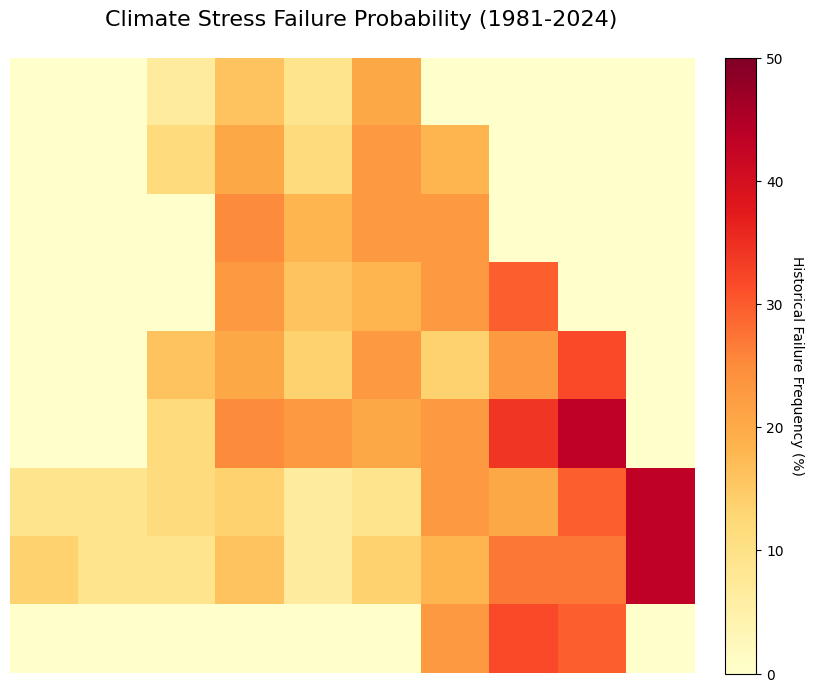

Max failure probability in Nandi: 43.18%
Mean failure probability across County: 12.20%


In [ ]:
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PATHS ---
# Match the folder name from your GEE script
failure_dir = '/content/drive/MyDrive/02_NandiSeedRecommender2/Climate_Extreme_Data/'
files = glob.glob(os.path.join(failure_dir, "Failure_LongRains_*.tif"))

if not files:
    print("No files found. Wait for GEE tasks to finish or check the path.")
else:
    # 1. Aggregate the failure files
    failure_stack = []
    for f in files:
        with rasterio.open(f) as src:
            data = src.read(1).astype('float32')
            # Handle background (GEE export might use 0 for both background and 'no failure')
            # Assuming nandi_roi clip handles the shape
            failure_stack.append(data)

    # Convert to 3D array: (Years, Height, Width)
    stack = np.array(failure_stack)

    # 2. Calculate Frequency (%)
    # Mean of 0s and 1s multiplied by 100
    failure_freq = np.mean(stack, axis=0) * 100

    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Using 'YlOrRd' (Yellow-Orange-Red) to represent risk/danger
    img = ax.imshow(failure_freq, cmap='YlOrRd', vmin=0, vmax=50)
    ax.axis('off')

    # Colorbar styling
    cbar = fig.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Historical Failure Frequency (%)', rotation=270, labelpad=15)

    # Aligned, non-bold title
    fig.text(0.5, 0.92, 'Climate Stress Failure Probability (1981-2024)',
             ha='center', fontsize=16, fontweight='normal')

    plt.show()

    # Quick Summary Stats
    print(f"Max failure probability in Nandi: {np.max(failure_freq):.2f}%")
    print(f"Mean failure probability across County: {np.mean(failure_freq):.2f}%")

###4. RONI

In [ ]:
import pandas as pd
data_path = pd.read_csv("/content/drive/MyDrive/02_NandiSeedRecommender2/Climate_Extreme_Data/RONI.csv")
data_path.head()

,Year,MAM,OND,LR_Phase,SR_Phase
0,1950,-1.09,-0.41,LN,N
1,1951,0.60,0.91,EN,EN
2,1952,0.44,-0.01,N,N
3,1953,0.83,0.81,EN,EN
4,1954,-0.20,-0.56,N,LN


###5. Salinity and Sodicity

We download all tif files from: https://files.isric.org/public/global_soil_salinity/salmap2016/ i.e. the 2016 Global Salinity Map. We then clip to Nandi using the code below.

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os
from glob import glob
import numpy as np

# 1. Load your Nandi Shapefile to use as the "cookie cutter"
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']

# 2. Point to your downloaded 2016 tiles
tile_folder = '/content/drive/MyDrive/02_NandiSeedRecommender2/Salinity_Sodicity_Data'
tiles = glob(os.path.join(tile_folder, "salMap2016*.tif"))

# 3. Automatic Tile Search, Clip, and Unit Normalization
found = False
for tile_path in tiles:
    with rasterio.open(tile_path) as src:
        # Align CRS for the spatial overlap check
        nandi_proj = nandi_gdf.to_crs(src.crs)
        nandi_bounds = nandi_proj.total_bounds
        tile_bounds = src.bounds

        # Check if Nandi's coordinates fall within this specific tile
        if not (nandi_bounds[2] < tile_bounds[0] or nandi_bounds[0] > tile_bounds[2] or
                nandi_bounds[3] < tile_bounds[1] or nandi_bounds[1] > tile_bounds[3]):

            print(f"Nandi detected in tile: {os.path.basename(tile_path)}")

            # Clip the data to the Nandi boundary
            out_image, out_transform = mask(src, nandi_proj.geometry, crop=True)

            # 4. Numerical Check based on Ivushkin et al. (2019)
            # The study uses ECe (dS/m). Some versions store data as dS/m * 10.
            # If the data sample mean is high, we normalize to standard dS/m.
            valid_data = out_image[out_image > 0]
            if valid_data.size > 0 and np.mean(valid_data) > 10:
                out_image = out_image / 10.0

            # 5. Save the Nandi-specific Salinity Map
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "dtype": 'float32'
            })

            output_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Images/Nandi_Salinity_2016_Final.tif'
            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image.astype('float32'))

            print(f"Success! Nandi salinity map saved to: {output_path}")
            found = True
            break

if not found:
    print("Nandi not found in the current tiles. Please ensure all 2016 tiles are in the folder.")

Nandi detected in tile: salMap2016-0000032768-0000065536.tif
Success! Nandi salinity map saved to: /content/drive/MyDrive/02_NandiSeedRecommender2/Images/Nandi_Salinity_2016_Final.tif


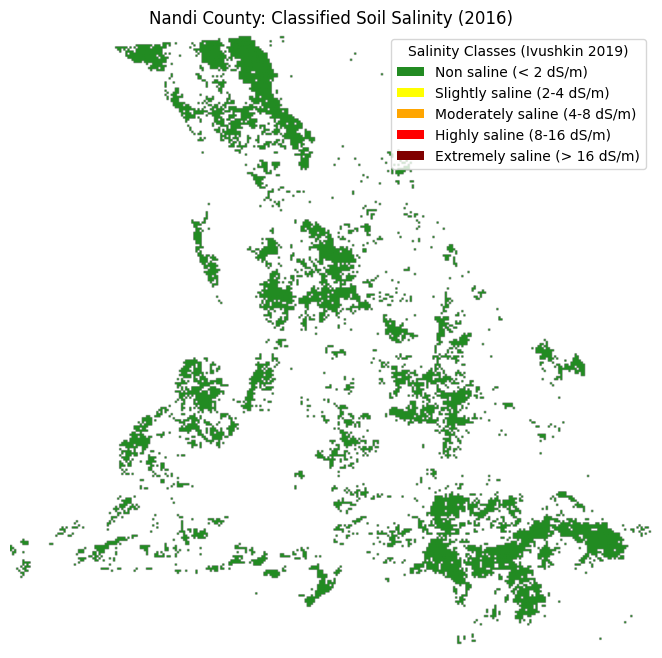

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch

file_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Salinity_Sodicity_Data/Nandi_Salinity_2016_Final.tif'

with rasterio.open(file_path) as src:
    salinity_data = src.read(1)

    # Masking zero/NoData values
    salinity_data = np.where(salinity_data == 0, np.nan, salinity_data)

# Define the Ivushkin et al. (2019) color scheme
# Green, Yellow, Orange, Red, Dark Red
colors = ['#228B22', '#FFFF00', '#FFA500', '#FF0000', '#800000']
cmap = mcolors.ListedColormap(colors)

# Define the legend labels
class_labels = [
    'Non saline (< 2 dS/m)',
    'Slightly saline (2-4 dS/m)',
    'Moderately saline (4-8 dS/m)',
    'Highly saline (8-16 dS/m)',
    'Extremely saline (> 16 dS/m)'
]

# Create bounds for the classes (1 to 5)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(12, 8))
# Display the map
img = plt.imshow(salinity_data, cmap=cmap, norm=norm)

# Create a custom legend
legend_elements = [Patch(facecolor=colors[i], label=class_labels[i]) for i in range(len(colors))]
plt.legend(handles=legend_elements, loc='upper right', title="Salinity Classes (Ivushkin 2019)")

plt.title('Nandi County: Classified Soil Salinity (2016)')
plt.axis('off')
plt.show()

###6. Exchangeable Sodium
We download from: https://data.isric.org/geonetwork/srv/api/records/df2c4602-03c4-4130-b7e5-2439e68bf415

--- Nandi Sodium (ENAX) Summary Statistics ---
Minimum Value: 0.0001 cmol+/kg
Maximum Value: 6.0200 cmol+/kg
Mean Value:    0.4647 cmol+/kg
Standard Dev:  0.3668 cmol+/kg
----------------------------------------


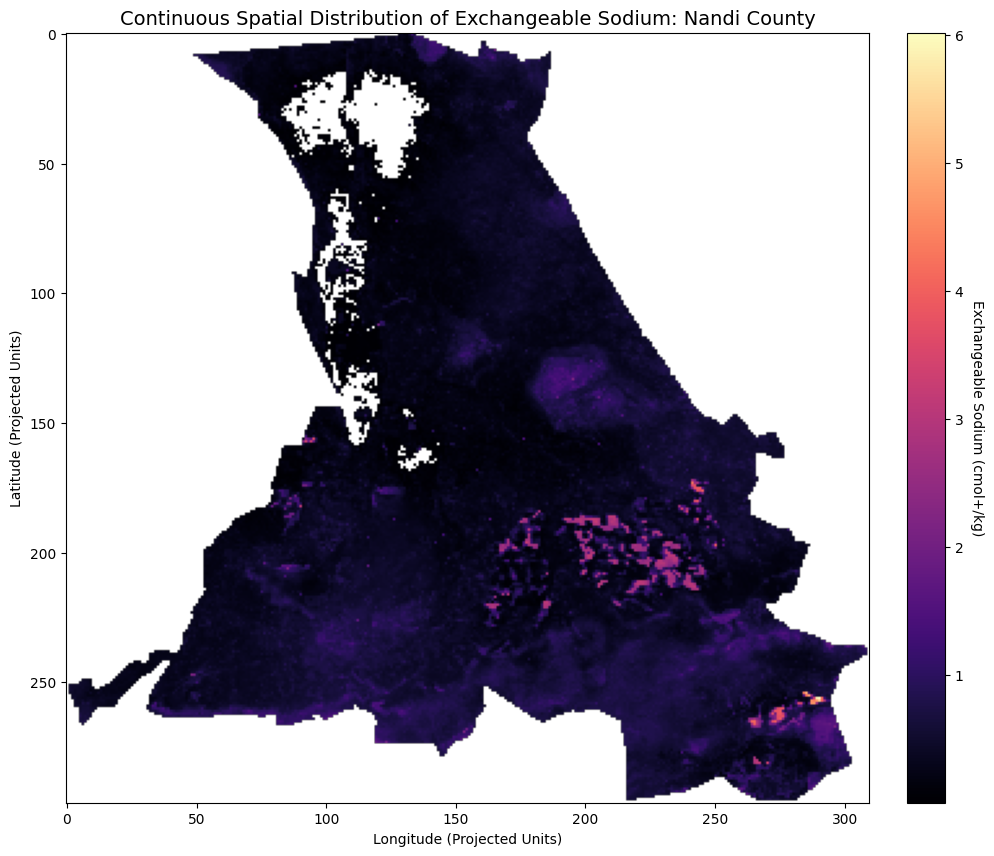

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup paths
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
enax_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Salinity_Sodicity_Data/af_ENAX_T__M_xd1_250m.tif'

# 2. Load and Clip
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']

with rasterio.open(enax_path) as src:
    # Match coordinate systems (ENAX is usually in LAEA projection)
    nandi_proj = nandi_gdf.to_crs(src.crs)

    # Clip the data
    out_image, out_transform = mask(src, nandi_proj.geometry, crop=True)
    out_image = out_image[0].astype('float32')

# 3. Data Processing for Visualization
# Replace 0 or NoData values with NaN to ensure they don't skew the heatmap
masked_map = np.where(out_image <= 0, np.nan, out_image)
valid_data = masked_map[~np.isnan(masked_map)]

if valid_data.size > 0:
    # Print statistics for your report
    print(f"--- Nandi Sodium (ENAX) Summary Statistics ---")
    print(f"Minimum Value: {np.nanmin(valid_data):.4f} cmol+/kg")
    print(f"Maximum Value: {np.nanmax(valid_data):.4f} cmol+/kg")
    print(f"Mean Value:    {np.nanmean(valid_data):.4f} cmol+/kg")
    print(f"Standard Dev:  {np.nanstd(valid_data):.4f} cmol+/kg")
    print("-" * 40)

    # 4. Continuous Heatmap Visualization
    plt.figure(figsize=(12, 10))

    # Using 'magma' or 'viridis' provides high perceptual contrast for soil gradients
    img = plt.imshow(masked_map, cmap='magma')

    # Add a colorbar to show the scale
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Exchangeable Sodium (cmol+/kg)', rotation=270, labelpad=15)

    plt.title('Continuous Spatial Distribution of Exchangeable Sodium: Nandi County', fontsize=14)
    plt.xlabel('Longitude (Projected Units)')
    plt.ylabel('Latitude (Projected Units)')
    plt.grid(False)
    plt.show()

else:
    print("Error: No valid data found within the Nandi county boundaries.")

###Plotting Salinity and Sodicity side by side

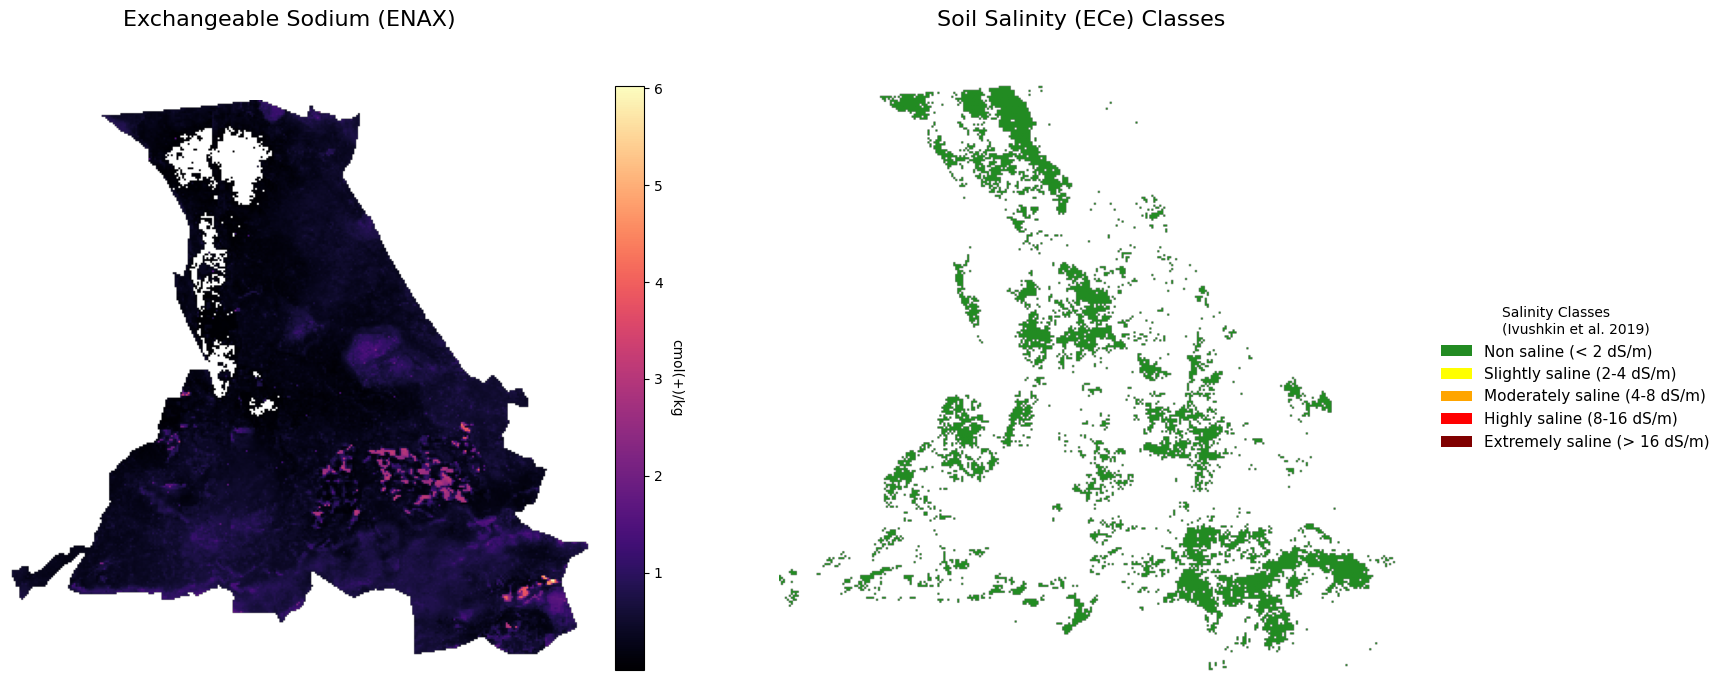

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# --- SETTINGS & PATHS ---
output_file = '/content/drive/MyDrive/02_NandiSeedRecommender2/Images/Nandi_Sodium_Salinity_Composite.png'
shapefile_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/NandiCounties/counties.shp'
enax_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Salinity_Sodicity_Data/af_ENAX_T__M_xd1_250m.tif'
salinity_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Salinity_Sodicity_Data/Nandi_Salinity_2016_Final.tif'

# 1. Load Geometries
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']

# 2. Process Sodium (ENAX) Data
with rasterio.open(enax_path) as src:
    nandi_proj = nandi_gdf.to_crs(src.crs)
    out_image_na, _ = mask(src, nandi_proj.geometry, crop=True)
    na_data = np.where(out_image_na[0] <= 0, np.nan, out_image_na[0].astype('float32'))

# 3. Process Salinity Data
with rasterio.open(salinity_path) as src:
    sal_data = src.read(1).astype('float32')
    sal_data = np.where(sal_data == 0, np.nan, sal_data)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot A: Exchangeable Sodium
img1 = ax1.imshow(na_data, cmap='magma')
ax1.axis('off')
cbar1 = fig.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('cmol(+)/kg', rotation=270, labelpad=15)

# Subplot B: Soil Salinity
sal_colors = ['#228B22', '#FFFF00', '#FFA500', '#FF0000', '#800000']
sal_cmap = mcolors.ListedColormap(sal_colors)
sal_labels = [
    'Non saline (< 2 dS/m)', 'Slightly saline (2-4 dS/m)',
    'Moderately saline (4-8 dS/m)', 'Highly saline (8-16 dS/m)',
    'Extremely saline (> 16 dS/m)'
]
sal_bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
sal_norm = mcolors.BoundaryNorm(sal_bounds, sal_cmap.N)

img2 = ax2.imshow(sal_data, cmap=sal_cmap, norm=sal_norm)
ax2.axis('off')

# Neater legend
legend_elements = [Patch(facecolor=sal_colors[i], label=sal_labels[i]) for i in range(len(sal_colors))]
ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5),
           title="Salinity Classes\n(Ivushkin et al. 2019)", frameon=False, fontsize=11)

# --- FORCE ALIGNED TITLES ---
# Use fig.text to place titles at an absolute vertical position (0.92)
# The first number (0.28 and 0.72) centers them over ax1 and ax2 respectively.
fig.text(0.28, 0.92, 'Exchangeable Sodium (ENAX)', ha='center', fontsize=16)
fig.text(0.72, 0.92, 'Soil Salinity (ECe) Classes', ha='center', fontsize=16)

plt.subplots_adjust(top=0.85) # Make room for the text titles at the top
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

###Elevation and Slope

In [ ]:
#Slope
import ee
import geopandas as gpd
import os

project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

shapefile_path = '/content/drive/MyDrive/01_Nandi_Seed_Recommender_System/NandiCounties/counties.shp'
output_folder = '01_Nandi_Seed_Recommender_System/Soil_Data'

gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
if nandi_gdf.empty:
    raise ValueError("Error: Could not find 'NANDI'.")

full_geom = nandi_gdf.union_all()
nandi_roi = ee.Geometry(full_geom.__geo_interface__)

elevation = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(elevation) # Calculates slope in Degrees

task = ee.batch.Export.image.toDrive(
    image=slope.clip(nandi_roi),
    description="Slope_Degrees",
    folder=output_folder,
    region=nandi_roi,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e9
)

task.start()
print("Monitor progress at: https://code.earthengine.google.com/tasks")

In [ ]:
#elevation
import ee
import geopandas as gpd

# 1. Initialize Earth Engine
project_id = 'nandi-seed-recommender'
try:
    ee.Initialize(project=project_id)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 2. Define the Region of Interest (Nandi)
shapefile_path = '/content/drive/MyDrive/01_Nandi_Seed_Recommender_System/NandiCounties/counties.shp'
gdf = gpd.read_file(shapefile_path)
nandi_gdf = gdf[gdf['COUNTY_NAM'] == 'NANDI']
full_geom = nandi_gdf.union_all()
nandi_roi = ee.Geometry(full_geom.__geo_interface__)

# 3. Load SRTM Elevation Data
# This is the 30m Global Digital Elevation Model (DEM)
elevation = ee.Image("USGS/SRTMGL1_003")

# 4. Export Task
output_folder = '01_Nandi_Seed_Recommender_System/Soil_Data'

task_elev = ee.batch.Export.image.toDrive(
    image=elevation.clip(nandi_roi),
    description="Elevation_30m",
    folder=output_folder,
    region=nandi_roi,
    scale=30,      # Matches your Slope and Soil data resolution
    crs='EPSG:4326',
    maxPixels=1e9
)

# Start the export
task_elev.start()

print("Elevation export started.")
print("Check progress at: https://code.earthengine.google.com/tasks")

In [ ]:
import rasterio
import numpy as np
import os

# --- PATHS ---
input_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Terrain_Data/NASA_SRTM_Slope_Degrees_30m.tif'
output_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Terrain_Data/Nandi_Slope_Percent.tif'

with rasterio.open(input_path) as src:
    # 1. Read the Degree data
    slope_deg = src.read(1).astype('float32')
    meta = src.meta.copy()

    # 2. Handle NoData
    # If SRTM has NaN or 0 as background, we treat it as NaN for the math
    mask = (slope_deg < 0) | np.isnan(slope_deg)

    # 3. Apply the Trigonometric Conversion
    # Formula: tan(deg * pi / 180) * 100
    slope_pct = np.tan(np.deg2rad(slope_deg)) * 100

    # 4. Clean up results
    # Re-apply the mask and cap physically impossible values at the borders
    slope_pct[mask] = np.nan
    slope_pct[slope_pct > 500] = np.nan # Cap extreme artifacts

    # 5. Save the processed Percentage file
    meta.update(dtype='float32', nodata=np.nan)
    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(slope_pct, 1)

# --- VERIFICATION ---
valid_data = slope_pct[~np.isnan(slope_pct)]
print(f"--- Conversion Complete ---")
print(f"Min Slope:  {np.nanmin(valid_data):.2f}%")
print(f"Max Slope:  {np.nanmax(valid_data):.2f}%")
print(f"Mean Slope: {np.nanmean(valid_data):.2f}%")

--- Conversion Complete ---
Min Slope:  0.00%
Max Slope:  218.70%
Mean Slope: 14.18%


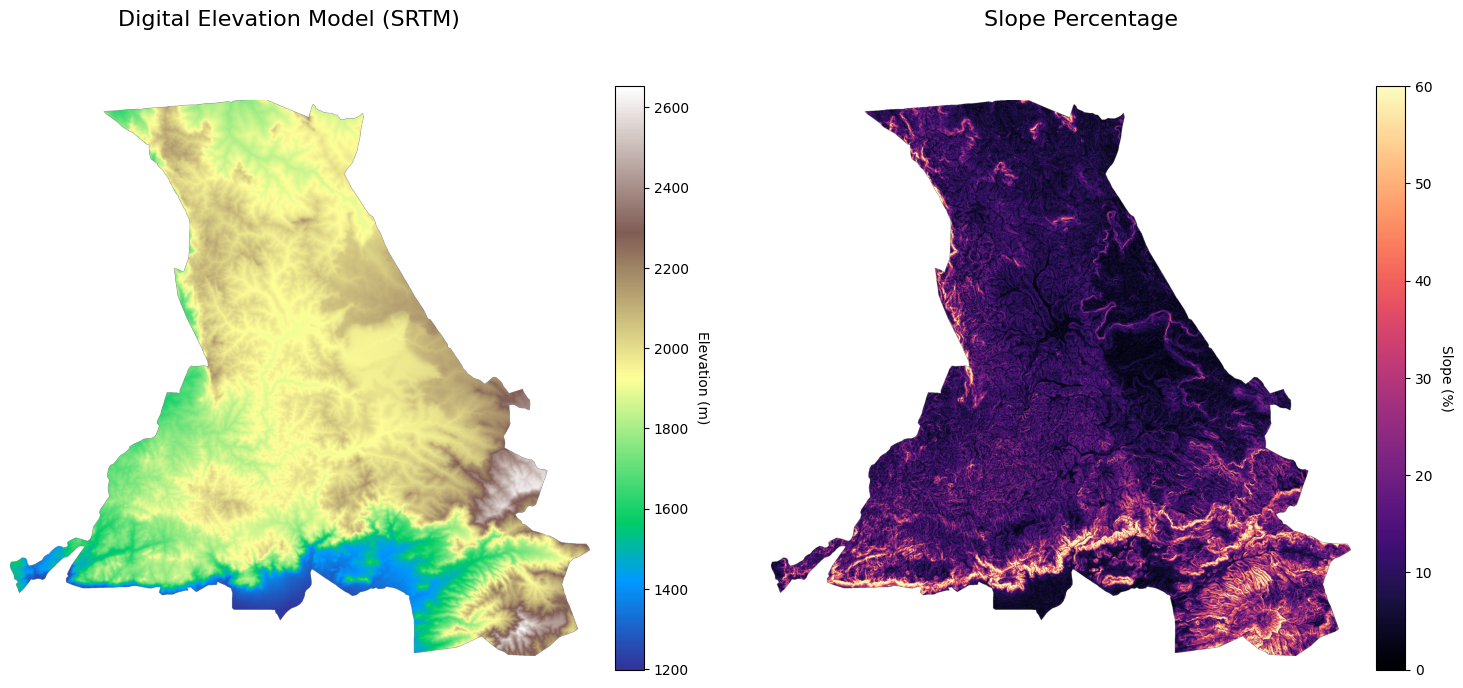

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# --- SETTINGS & PATHS ---
elev_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Terrain_Data/NASA_SRTM_Elevation_30m.tif'
slope_path = '/content/drive/MyDrive/02_NandiSeedRecommender2/Terrain_Data/Nandi_Slope_Percent.tif'
output_file = '/content/drive/MyDrive/02_NandiSeedRecommender2/Images/Nandi_Terrain_Composite.png'

# 1. Load Elevation Data
with rasterio.open(elev_path) as src:
    elev_data = src.read(1).astype('float32')
    # Masking values <= 0 (background)
    elev_data[elev_data <= 0] = np.nan

# 2. Load Slope Data
with rasterio.open(slope_path) as src:
    slope_data = src.read(1).astype('float32')
    # Masking negative values
    slope_data[slope_data < 0] = np.nan

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Subplot A: Elevation
img1 = ax1.imshow(elev_data, cmap='terrain')
ax1.axis('off')
cbar1 = fig.colorbar(img1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Elevation (m)', rotation=270, labelpad=15)

# Subplot B: Slope (%)
# Using 'magma' or 'viridis' for slope; vmin/vmax at 0-60 ensures contrast
img2 = ax2.imshow(slope_data, cmap='magma', vmin=0, vmax=60)
ax2.axis('off')
cbar2 = fig.colorbar(img2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Slope (%)', rotation=270, labelpad=15)

# --- ALIGNED TITLES (NOT BOLD) ---
# 0.92 is the vertical height. 0.28 and 0.72 center the text over the subplots.
fig.text(0.28, 0.92, 'Digital Elevation Model (SRTM)',
         ha='center', fontsize=16, fontweight='normal')
fig.text(0.72, 0.92, 'Slope Percentage',
         ha='center', fontsize=16, fontweight='normal')

# Adjust layout to accommodate absolute text
plt.subplots_adjust(top=0.85)

# Save and Show
plt.savefig(output_file, dpi=120, bbox_inches='tight')
plt.show()